In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('weather_data.csv')
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [17]:
df['date']=pd.to_datetime(df['date'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


In [19]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [20]:
df.index

RangeIndex(start=0, stop=1462, step=1)

In [21]:
#Make our Month column as an index
df.index=df['date']
df

,date,meantemp,humidity,wind_speed,meanpressure
date,,,,,
2013-01-01,2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
2016-12-28,2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,2016-12-30,14.095238,89.666667,6.266667,1017.904762


In [22]:
#Delete the extra column
del df['date']


In [23]:
df

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,14.095238,89.666667,6.266667,1017.904762


In [25]:
full_range=pd.date_range(start=df.index.min(),end=df.index.max(),freq='MS')

full_range  

DatetimeIndex(['2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01',
               '2013-05-01', '2013-06-01', '2013-07-01', '2013-08-01',
               '2013-09-01', '2013-10-01', '2013-11-01', '2013-12-01',
               '2014-01-01', '2014-02-01', '2014-03-01', '2014-04-01',
               '2014-05-01', '2014-06-01', '2014-07-01', '2014-08-01',
               '2014-09-01', '2014-10-01', '2014-11-01', '2014-12-01',
               '2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01',
               '2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01',
               '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01',
               '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01',
               '2017-01-01'],
              dtype='datetime64[ns]', freq='MS')

In [26]:
misssing_TS=full_range.difference(df.index)
misssing_TS

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

<Axes: xlabel='date'>

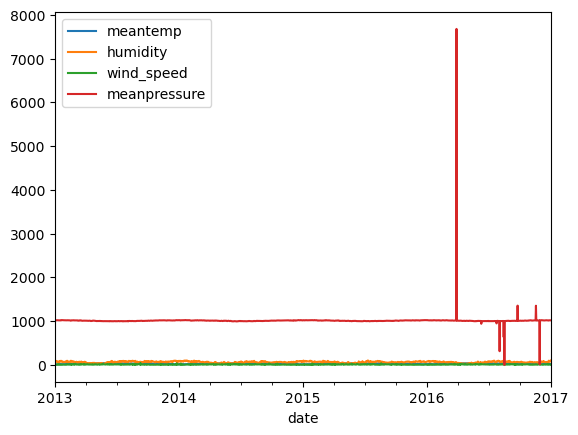

In [27]:
df.plot()

<Figure size 1800x500 with 0 Axes>

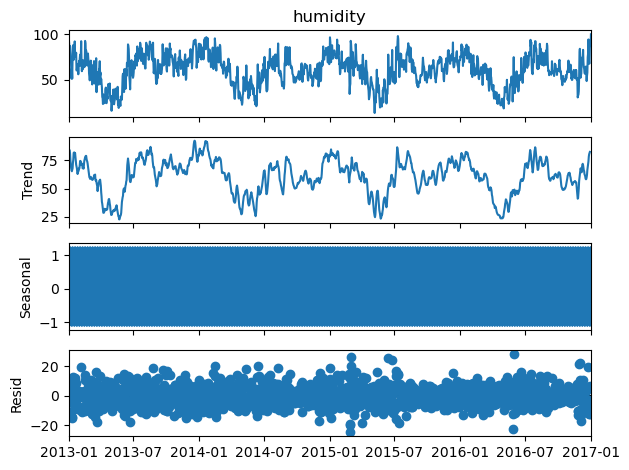

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(18,5))
decompose=seasonal_decompose(df['humidity'])
decompose.plot();

In [31]:
from statsmodels.tsa.stattools import adfuller

In [33]:
result=adfuller(df['humidity'])
result

(np.float64(-3.6755769191633414),
 np.float64(0.004470100478130723),
 15,
 1446,
 {'1%': np.float64(-3.434880391815318),
  '5%': np.float64(-2.8635408625359315),
  '10%': np.float64(-2.5678352438452814)},
 np.float64(9961.530007876658))

In [34]:
p_value=result[1]

In [35]:
p_value

np.float64(0.004470100478130723)

In [36]:
if p_value<=0.05:
  print('Data is statinary')
else:
  print('Data is not statioanry')

Data is statinary


In [37]:
from pandas.core.window.rolling import Window
rolling_mean=df.rolling(window=12).mean()
rolling_std=df.rolling(window=12).std()

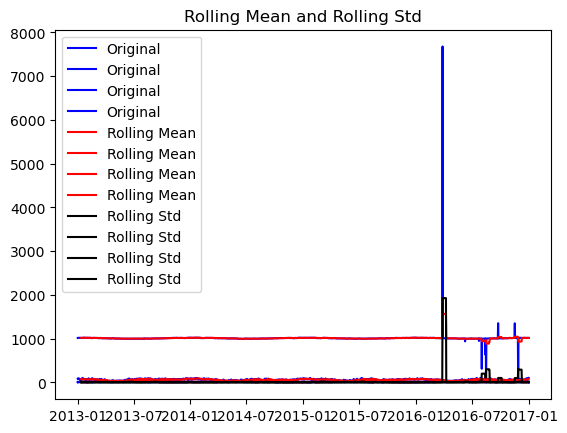

In [38]:
plt.plot(df,color='blue',label='Original')
plt.plot(rolling_mean,color='red',label='Rolling Mean')
plt.plot(rolling_std,color='black',label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std')
plt.show()

In [39]:
log_df=np.log(df)

c:\conda_envs\Projects\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\conda_envs\Projects\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [40]:
log_df

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,2.302585,4.436752,-inf,6.923300
2013-01-02,2.001480,4.521789,1.091923,6.925399
2013-01-03,1.969441,4.465908,1.533277,6.926250
2013-01-04,2.159484,4.267364,0.209721,6.924776
2013-01-05,1.791759,4.463991,1.308333,6.924121
...,...,...,...,...
2016-12-28,2.845920,4.220147,1.266335,6.923201
2016-12-29,2.723799,4.475712,1.791759,6.924519
2016-12-30,2.645837,4.496099,1.835245,6.925502


In [41]:
rolling_mean=log_df.rolling(window=12).mean()
rolling_std=log_df.rolling(window=12).std()

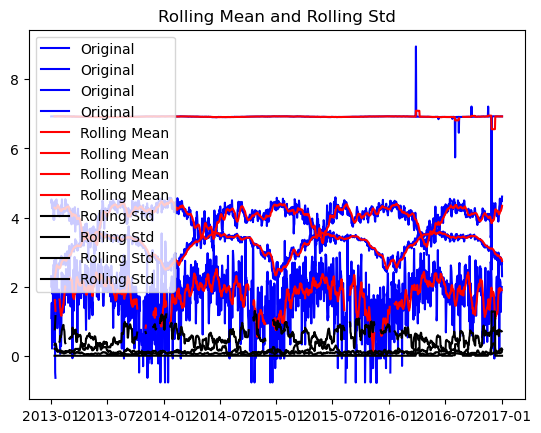

In [42]:
plt.plot(log_df,color='blue',label='Original')
plt.plot(rolling_mean,color='red',label='Rolling Mean')
plt.plot(rolling_std,color='black',label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std')
plt.show()